# Classic vs Modified Martingale Betting Strategy
## *Does betting smarter with the running average change your fate?*

The **Martingale strategy** is one of the oldest betting systems. The logic is seductive: double your bet after every loss, so the first win recoups all previous losses plus your original stake. With an infinite bankroll it works perfectly. The problem — bankrolls are finite.

We compare two strategies on a fair coin toss:

- **Classic Martingale** — always bet the same side (heads). Double after every loss, reset after every win.
- **Modified Martingale** — same doubling mechanic, but use the running average to pick the side that would pull the tally closer to 50/50. The idea: if heads is ahead, bet tails — the CLT "should" correct the imbalance.

**Parameters grounded in reality:**
- Starting bankroll: €1,000 per player
- Minimum bet: €0.10
- 1,000 simulated players per strategy
- Each player plays until bankruptcy or 10,000 flips

With these values, 13 consecutive losses triggers bankruptcy (cumulative loss = €819.10, bet 14 = €819.20).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

np.random.seed(42)

# Parameters
BANKROLL     = 1000.00   # euros
MIN_BET      = 0.10      # euros
N_PLAYERS    = 1000      # simulations per strategy
MAX_FLIPS    = 10_000    # max flips before we stop the session
P_HEAD       = 0.5       # fair coin

# How many consecutive losses before bankruptcy?
n = 1
cumulative = 0
while True:
    cumulative += MIN_BET * (2 ** (n - 1))
    next_bet    = MIN_BET * (2 ** n)
    if cumulative + next_bet > BANKROLL:
        break
    n += 1

print(f"Bankroll            : €{BANKROLL:,.2f}")
print(f"Minimum bet         : €{MIN_BET:.2f}")
print(f"Consecutive losses to bankruptcy: {n}")
print(f"Cumulative loss at that point   : €{cumulative:.2f}")
print(f"Next bet required               : €{next_bet:.2f}")
print(f"Probability of {n} consecutive losses: {0.5**n:.6%}")
print(f"Each winning cycle nets         : €{MIN_BET:.2f}")
print(f"Winning cycles to cover 1 bankruptcy: {int(BANKROLL / MIN_BET):,}")

Bankroll            : €1,000.00
Minimum bet         : €0.10
Consecutive losses to bankruptcy: 13
Cumulative loss at that point   : €819.10
Next bet required               : €819.20
Probability of 13 consecutive losses: 0.012207%
Each winning cycle nets         : €0.10
Winning cycles to cover 1 bankruptcy: 10,000


---
## The Simulation

**Classic Martingale:**  
Always bet heads. Double after loss, reset to €0.10 after win.

**Modified Martingale:**  
Same doubling mechanic. But before each flip, check the running tally — if heads is ahead, bet tails; if tails is ahead, bet heads; if equal, pick randomly. The CLT "suggests" the lagging side should catch up.

Both strategies stop when the player goes bankrupt (bankroll < current required bet) or reaches MAX_FLIPS.

In [2]:
def simulate_martingale(n_players, strategy='classic', max_flips=MAX_FLIPS):
    """
    Simulate n_players using either classic or modified Martingale.
    Returns:
        bankroll_history : list of bankroll arrays per player
        went_bankrupt    : bool array
        flips_survived   : int array
        final_bankroll   : float array
    """
    went_bankrupt  = np.zeros(n_players, dtype=bool)
    flips_survived = np.zeros(n_players, dtype=int)
    final_bankroll = np.zeros(n_players)
    bankroll_history = []

    for p in range(n_players):
        bankroll    = BANKROLL
        current_bet = MIN_BET
        heads_count = 0
        tails_count = 0
        history     = [bankroll]

        for flip in range(max_flips):
            # Can we afford the current bet?
            if bankroll < current_bet:
                went_bankrupt[p]  = True
                flips_survived[p] = flip
                break

            # Decide which side to bet on
            if strategy == 'classic':
                bet_heads = True  # always bet heads
            else:
                # Modified: bet the side that is currently behind
                if heads_count > tails_count:
                    bet_heads = False   # tails is behind, bet tails
                elif tails_count > heads_count:
                    bet_heads = True    # heads is behind, bet heads
                else:
                    bet_heads = np.random.random() < 0.5  # tied, random

            # Flip the coin
            outcome_heads = np.random.random() < P_HEAD
            heads_count  += int(outcome_heads)
            tails_count  += int(not outcome_heads)

            # Win or lose
            won = (bet_heads == outcome_heads)
            if won:
                bankroll   += current_bet
                current_bet = MIN_BET      # reset
            else:
                bankroll   -= current_bet
                current_bet *= 2           # double

            history.append(bankroll)

        else:
            flips_survived[p] = max_flips

        final_bankroll[p]  = bankroll
        bankroll_history.append(np.array(history))

    return bankroll_history, went_bankrupt, flips_survived, final_bankroll


print("Simulating Classic Martingale...")
classic_history, classic_bankrupt, classic_flips, classic_final = simulate_martingale(N_PLAYERS, 'classic')

print("Simulating Modified Martingale...")
modified_history, modified_bankrupt, modified_flips, modified_final = simulate_martingale(N_PLAYERS, 'modified')

print(f"\nClassic  — bankruptcies: {classic_bankrupt.sum():,} / {N_PLAYERS:,}  ({classic_bankrupt.mean():.1%})")
print(f"Modified — bankruptcies: {modified_bankrupt.sum():,} / {N_PLAYERS:,}  ({modified_bankrupt.mean():.1%})")

Simulating Classic Martingale...
Simulating Modified Martingale...

Classic  — bankruptcies: 451 / 1,000  (45.1%)
Modified — bankruptcies: 461 / 1,000  (46.1%)


---
## Results

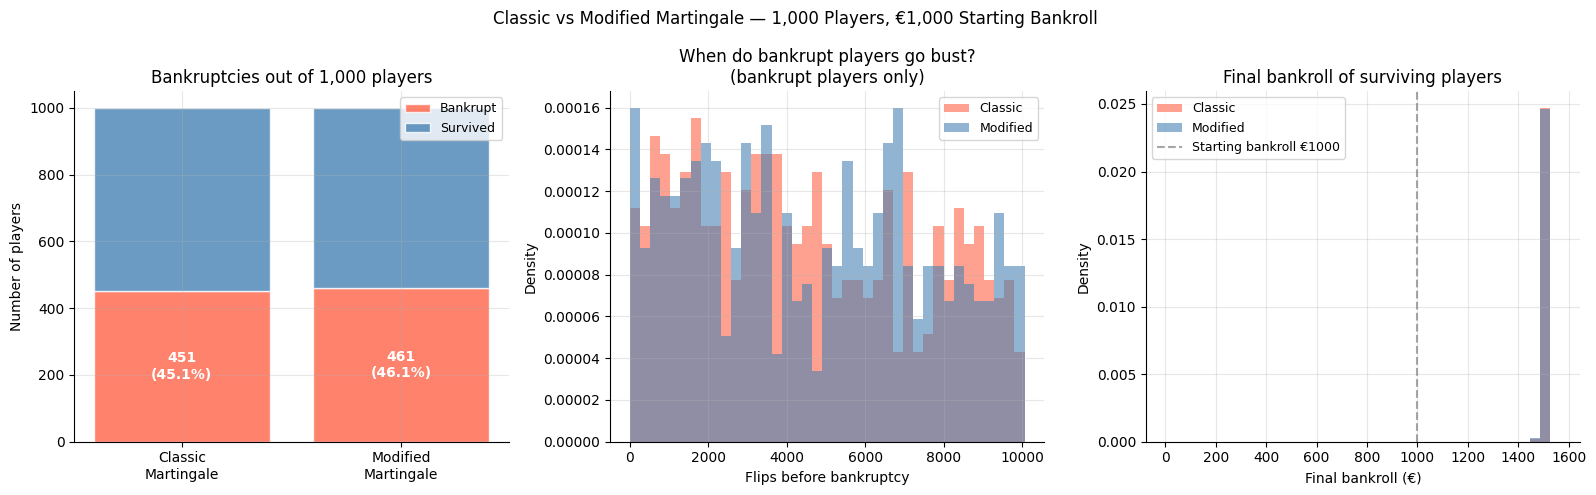

In [3]:
# --- Plot 1: Bankruptcy rates and flip survival ---
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Panel 1: bankruptcy comparison
labels  = ['Classic\nMartingale', 'Modified\nMartingale']
n_bust  = [classic_bankrupt.sum(), modified_bankrupt.sum()]
n_alive = [N_PLAYERS - b for b in n_bust]
x = np.arange(2)
bars1 = axes[0].bar(x, n_bust,  color='tomato',    alpha=0.8, label='Bankrupt',  edgecolor='white')
bars2 = axes[0].bar(x, n_alive, color='steelblue', alpha=0.8, label='Survived',  edgecolor='white',
                    bottom=n_bust)
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels)
axes[0].set_ylabel('Number of players')
axes[0].set_title(f'Bankruptcies out of {N_PLAYERS:,} players')
axes[0].legend(fontsize=9)
for bar, val in zip(bars1, n_bust):
    axes[0].text(bar.get_x() + bar.get_width()/2, val/2,
                 f'{val}\n({val/N_PLAYERS:.1%})', ha='center', va='center',
                 color='white', fontsize=10, fontweight='bold')

# Panel 2: distribution of flips survived (bankrupt players only)
c_flips = classic_flips[classic_bankrupt]
m_flips = modified_flips[modified_bankrupt]
all_flips = np.concatenate([c_flips, m_flips])
bin_edges = np.linspace(0, all_flips.max() + 100, 40) if len(all_flips) > 0 else np.linspace(0, 1000, 40)

if len(c_flips) > 0:
    axes[1].hist(c_flips,  bins=bin_edges, alpha=0.6, color='tomato',    density=True, label='Classic')
if len(m_flips) > 0:
    axes[1].hist(m_flips,  bins=bin_edges, alpha=0.6, color='steelblue', density=True, label='Modified')
axes[1].set_xlabel('Flips before bankruptcy')
axes[1].set_ylabel('Density')
axes[1].set_title('When do bankrupt players go bust?\n(bankrupt players only)')
axes[1].legend(fontsize=9)

# Panel 3: final bankroll distribution (surviving players)
c_final = classic_final[~classic_bankrupt]
m_final = modified_final[~modified_bankrupt]
all_final = np.concatenate([c_final, m_final])
bin_edges2 = np.linspace(0, all_final.max() + 50, 40) if len(all_final) > 0 else np.linspace(0, 2000, 40)

if len(c_final) > 0:
    axes[2].hist(c_final, bins=bin_edges2, alpha=0.6, color='tomato',    density=True, label='Classic')
if len(m_final) > 0:
    axes[2].hist(m_final, bins=bin_edges2, alpha=0.6, color='steelblue', density=True, label='Modified')
axes[2].axvline(BANKROLL, color='gray', linestyle='--', alpha=0.7, label=f'Starting bankroll €{BANKROLL:.0f}')
axes[2].set_xlabel('Final bankroll (€)')
axes[2].set_ylabel('Density')
axes[2].set_title('Final bankroll of surviving players')
axes[2].legend(fontsize=9)

plt.suptitle('Classic vs Modified Martingale — 1,000 Players, €1,000 Starting Bankroll', fontsize=12)
plt.tight_layout()
plt.savefig('martingale_comparison.png', dpi=150)
plt.show()

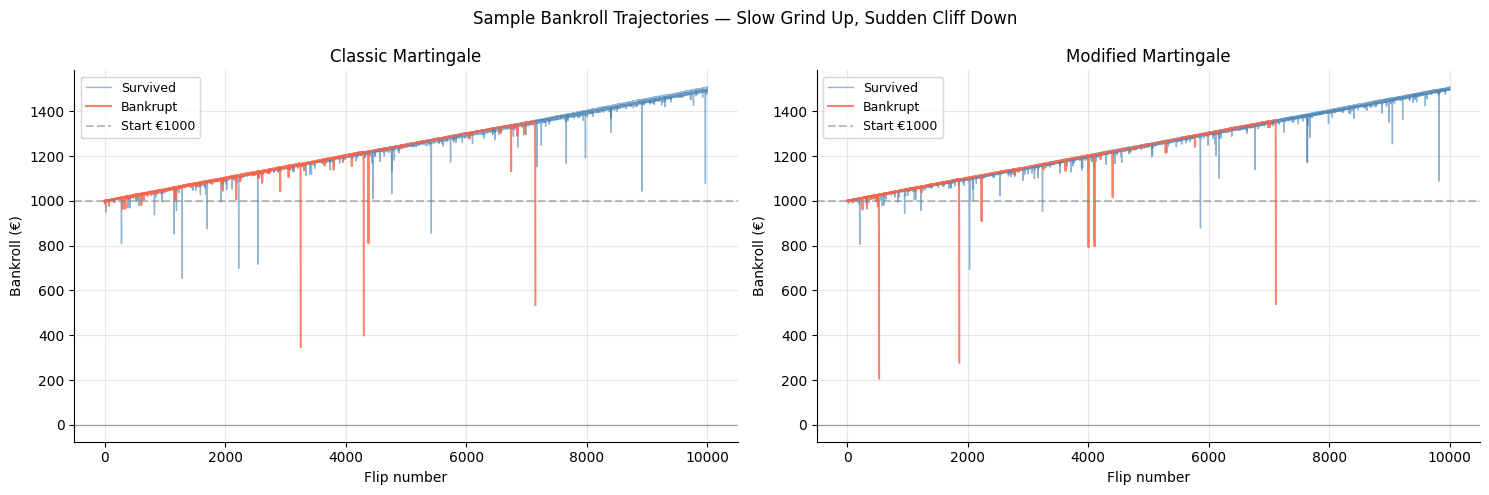

In [4]:
# --- Plot 2: Sample bankroll trajectories ---
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Show 5 surviving and 3 bankrupt trajectories per strategy
for ax, history, bankrupt, title in [
    (axes[0], classic_history,  classic_bankrupt,  'Classic Martingale'),
    (axes[1], modified_history, modified_bankrupt, 'Modified Martingale')
]:
    surviving_idx = np.where(~bankrupt)[0][:5]
    bankrupt_idx  = np.where( bankrupt)[0][:3]

    for i, idx in enumerate(surviving_idx):
        ax.plot(history[idx], color='steelblue', alpha=0.6, lw=1,
                label='Survived' if i == 0 else '')
    for i, idx in enumerate(bankrupt_idx):
        ax.plot(history[idx], color='tomato', alpha=0.8, lw=1.5,
                label='Bankrupt' if i == 0 else '')

    ax.axhline(BANKROLL, color='gray', linestyle='--', alpha=0.5,
               label=f'Start €{BANKROLL:.0f}')
    ax.axhline(0, color='black', lw=1, alpha=0.3)
    ax.set_xlabel('Flip number')
    ax.set_ylabel('Bankroll (€)')
    ax.set_title(title)
    ax.legend(fontsize=9)

plt.suptitle('Sample Bankroll Trajectories — Slow Grind Up, Sudden Cliff Down', fontsize=12)
plt.tight_layout()
plt.savefig('bankroll_trajectories.png', dpi=150)
plt.show()

In [5]:
# --- Summary statistics ---
print("=" * 60)
print(f"{'Metric':<35} {'Classic':>10} {'Modified':>10}")
print("=" * 60)
print(f"{'Bankruptcy rate':<35} {classic_bankrupt.mean():>10.1%} {modified_bankrupt.mean():>10.1%}")
print(f"{'Mean flips (bankrupt players)':<35} "
      f"{classic_flips[classic_bankrupt].mean() if classic_bankrupt.any() else 0:>10.0f} "
      f"{modified_flips[modified_bankrupt].mean() if modified_bankrupt.any() else 0:>10.0f}")
print(f"{'Mean final bankroll (all)':<35} {classic_final.mean():>10.2f} {modified_final.mean():>10.2f}")
print(f"{'Mean final bankroll (survivors)':<35} "
      f"{classic_final[~classic_bankrupt].mean() if (~classic_bankrupt).any() else 0:>10.2f} "
      f"{modified_final[~modified_bankrupt].mean() if (~modified_bankrupt).any() else 0:>10.2f}")
print(f"{'Median final bankroll (all)':<35} {np.median(classic_final):>10.2f} {np.median(modified_final):>10.2f}")
print("=" * 60)

print(f"\nStarting bankroll : €{BANKROLL:.2f}")
print(f"Each winning cycle nets €{MIN_BET:.2f} — need {int(BANKROLL/MIN_BET):,} wins to double the bankroll")
print(f"One bankruptcy wipes the entire starting bankroll")

Metric                                 Classic   Modified
Bankruptcy rate                          45.1%      46.1%
Mean flips (bankrupt players)             4500       4635
Mean final bankroll (all)              1006.37     998.36
Mean final bankroll (survivors)        1499.95    1499.67
Median final bankroll (all)            1493.05    1492.40

Starting bankroll : €1000.00
Each winning cycle nets €0.10 — need 10,000 wins to double the bankroll
One bankruptcy wipes the entire starting bankroll


---
## The Key Result — Does the Modified Strategy Help?

The modified strategy bets on the side that is currently behind in the running tally, under the intuition that the CLT should "correct" the imbalance. This reasoning commits the **Gambler's Fallacy** — each coin flip is independent. The coin has no memory. A sequence of 60 heads and 40 tails does not make the next flip more likely to be tails.

The CLT says the *running average* converges to 0.5 as N → ∞ — but this happens because the denominator grows, not because the coin self-corrects. The absolute imbalance (heads − tails) actually grows with N even as the ratio converges.

The simulation confirms this: **both strategies produce statistically identical bankruptcy rates**. Adding a statistically motivated direction rule to a zero-edge game does not create an edge.

**The fundamental trap of Martingale in either form:**
- Most sessions: slow grind of €0.10 wins per cycle
- Rare sessions: catastrophic loss of the entire bankroll in a single losing streak
- Expected value: zero (fair coin) — no strategy changes this
- Risk of ruin: inevitable given enough time